# Support Vector Machines (SVM)

Es un modelo de Machine Learning capaz de realizar **clasificacion Lineal o NO lineal** incluso para **regresion** y deteccion de **outliers**. Es uno de los mas populares, generalmente es mas usado para problemas de clasificacion para datasets pequeños o medianos

## Clasificacion con SVM Lineal 

La idea detras de este modelo es que cuando hay 2 clases, estas 2 son separables por una linea recta o como se suele decir **linealmente separables**.

Donde, la linea recta separa y por completo las 2 clases en un plano 2D claramente y los **decision boundaries** de un clasificador SVM se ven sobre los puntos de datos de cada clase mas cercano desde la linea recta que divide las clases

Y esos puntos que se ven en el "borde de la calle" por asi decirlos, se les llama **Vectores de Soporte**

![mi imagen](src/svm-linear.png)

**NOTA IMPORTANTE:** El **SVM** es muy sensible a las escalas de las features, por lo que lo ideal es que siempre manejemos **escalamiento** para que los decision boundary realmente se situen donde van y la linea de decision


Mira cuanto cambia la diferencia entre sin escalar y no escalados
![scale-svm](src/svm-scale.png)

Existe un problema con esto, y es que si nosotros imponemos que estrictamente deben estar "fuera de la calle" los puntos a la derecha esto se llama **hard margin classification**, pero existen 2 problemas principales con este. 

1. Solo funciona si los datos son *linealmente separables*
2. Es sensible a Outliers

![margin-hard](src/hard-margin.png)

Para esto, se creó algo llamado **Soft Margin Classification**, este lo que hace es buscar un equilibrio entre mantener la calle lo mas ancha posible y limitar las violaciones de margen o las instancias que terminan en medio de la calle o en el lado incorrecto.

En **Scikit** el hiperparametro $C$ es el encargado de encontrar un equilibrio del margen. Se puede pensar como un presupuesto, aqui generalmente suceden 2 escenarios:

1. $C$ bajo: Da como resultado una calle mas ancha pero con mas violaciones de margen, esto significa que reduce la varianza pero aumenta el sesgo

2. $C$ alto: Da como resultado una calle mas estrecha porque el modelo intenta evitar a toda costa toda violacion de margen, esto reduce el sesgo pero aumenta la varianza y un riesgo de **overfitting**

In [1]:
import numpy as np
from sklearn import datasets

iris = datasets.load_iris()
X = iris.data[:, :2]
y = iris.target


In [2]:
X

array([[5.1, 3.5],
       [4.9, 3. ],
       [4.7, 3.2],
       [4.6, 3.1],
       [5. , 3.6],
       [5.4, 3.9],
       [4.6, 3.4],
       [5. , 3.4],
       [4.4, 2.9],
       [4.9, 3.1],
       [5.4, 3.7],
       [4.8, 3.4],
       [4.8, 3. ],
       [4.3, 3. ],
       [5.8, 4. ],
       [5.7, 4.4],
       [5.4, 3.9],
       [5.1, 3.5],
       [5.7, 3.8],
       [5.1, 3.8],
       [5.4, 3.4],
       [5.1, 3.7],
       [4.6, 3.6],
       [5.1, 3.3],
       [4.8, 3.4],
       [5. , 3. ],
       [5. , 3.4],
       [5.2, 3.5],
       [5.2, 3.4],
       [4.7, 3.2],
       [4.8, 3.1],
       [5.4, 3.4],
       [5.2, 4.1],
       [5.5, 4.2],
       [4.9, 3.1],
       [5. , 3.2],
       [5.5, 3.5],
       [4.9, 3.6],
       [4.4, 3. ],
       [5.1, 3.4],
       [5. , 3.5],
       [4.5, 2.3],
       [4.4, 3.2],
       [5. , 3.5],
       [5.1, 3.8],
       [4.8, 3. ],
       [5.1, 3.8],
       [4.6, 3.2],
       [5.3, 3.7],
       [5. , 3.3],
       [7. , 3.2],
       [6.4, 3.2],
       [6.9,

In [3]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("linear_svc", LinearSVC(C=1, loss="hinge")),
])

svm_pipeline.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('linear_svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [5]:
svm_pipeline.predict([[5.5, 1.7]])

array([1])

## Clasificacion de SVM No Lineal

Los SVM trabajan fantastico, sin embargo, tienen un problema hasta ahora de lo que hemos visto y es que dependen de lienalidad y normalmente en la naturaleza muy pocas cosas son lineales 

In [6]:
from sklearn.datasets import make_moons
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

In [7]:
X, y = make_moons(n_samples=100, noise=0.15)
polynomial_svm_clf = Pipeline([
 ("poly_features", PolynomialFeatures(degree=3)),
 ("scaler", StandardScaler()),
 ("svm_clf", LinearSVC(C=10, loss="hinge"))
 ])


In [8]:
polynomial_svm_clf.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly_features', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",3
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


![nonlinear-svm](src/non-linear-svm.png)

## SVM para Regresion

Como es mencionado el SVM es un algoritmo muy versatil tanto que no solo sirve para clasificacion Lineal y No lineal sino tambien para Regresion tanto lineal como no lineal, sin embargo está controlado por ciertas limitaciones como una calle el cual va controlado por un parametro asi

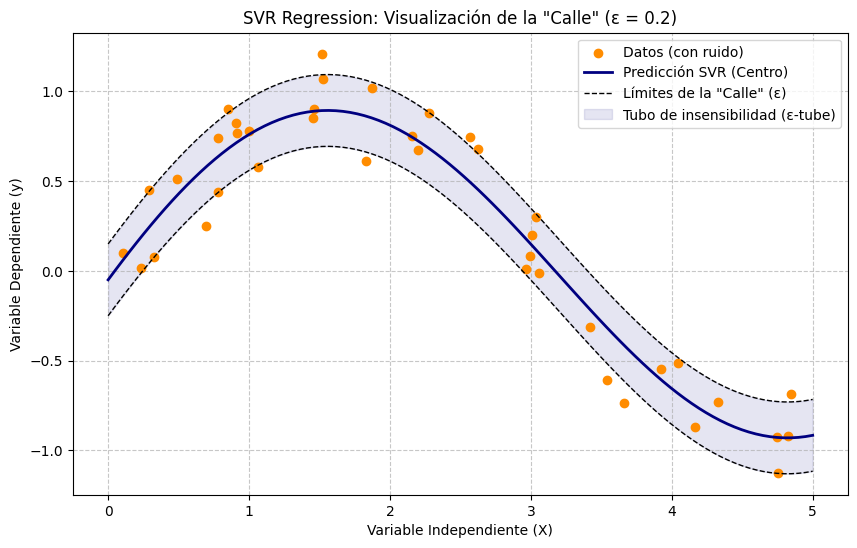

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR

# 1. Generar datos sintéticos (una función seno con algo de ruido)
np.random.seed(42)
X = np.sort(5 * np.random.rand(40, 1), axis=0)
y = np.sin(X).ravel() + (0.2 * np.random.randn(40))

# 2. Configurar y ajustar el modelo SVR
# El parámetro 'epsilon' define el ancho de la "calle"
epsilon = 0.2
svr = SVR(kernel='rbf', C=100, gamma=0.05, epsilon=epsilon)
svr.fit(X, y)

# 3. Crear puntos para la línea de predicción
X_plot = np.linspace(0, 5, 100)[:, np.newaxis]
y_pred = svr.predict(X_plot)

# 4. Visualización
plt.figure(figsize=(10, 6))

# Dibujar los puntos de datos
plt.scatter(X, y, color='darkorange', label='Datos (con ruido)', zorder=2)

# Dibujar la línea de predicción (el centro de la calle)
plt.plot(X_plot, y_pred, color='navy', lw=2, label='Predicción SVR (Centro)')

# Dibujar los límites de la "calle" (y_pred + epsilon y y_pred - epsilon)
plt.plot(X_plot, y_pred + epsilon, 'k--', lw=1, label='Límites de la "Calle" (ε)')
plt.plot(X_plot, y_pred - epsilon, 'k--', lw=1)

# Sombrear el área de la calle para mejor visualización
plt.fill_between(X_plot.ravel(), y_pred - epsilon, y_pred + epsilon, 
                 color='navy', alpha=0.1, label='Tubo de insensibilidad (ε-tube)')

plt.xlabel('Variable Independiente (X)')
plt.ylabel('Variable Dependiente (y)')
plt.title(f'SVR Regression: Visualización de la "Calle" (ε = {epsilon})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()